# FABN Bond Portfolio Optimizer — Gurobi  *(v2 — Lending Facility + Cash Shielding + Bond Liquidation)*

**Goal:** Maximize the Net Economic Value (NEV) of a Funding Agreement-Backed Note (FABN)
strategy by optimally allocating capital $h_i$ across a fixed-income universe.

---

## Objective Function

$$
\max_{h} \left[
\underbrace{\sum_{i \in \mathcal{S}} \bigl(Spread_i + \beta\, Signal_i\bigr)\, h_i}_{\text{Relative Value}}
\;-\;
\gamma \underbrace{\bigl(C_1(h) + C_3(h)\bigr)}_{\text{Capital cost}}
\;-\;
\underbrace{\sum_{i} \tau_i\, |h_i - h_i^{curr}|}_{\text{Transaction cost}}
\right]
$$

CF shortfall is **not** penalised in the objective — it is controlled entirely by the lending-facility hard cap constraint (see Linearization below).

| Component | Formula | Notes |
|---|---|---|
| $Spread_i$ | $y_i - r^{FABN}$ | Yield minus funding rate |
| $C_1(h)$ | $\sum_i \theta_i h_i$ | C-1 credit risk capital |
| $C_3(h)$ | $\alpha \left\lvert \sum_i D_i h_i - D^{FABN} H \right\rvert$ | C-3 ALM mismatch; $H = \sum_i h_i$ fixed by budget |

---

## Linearization & CF Shortfall Control

All nonlinear terms are reformulated using auxiliary variables and linear constraints, resulting in a standard linear program (LP) solvable by Gurobi.

- Absolute Value: |x| → d⁺ + d⁻
- Max: max(0, x) → two non-negative variables whose difference equals the argument

| Nonlinear term | Auxiliary vars | LP reformulation |
|---|---|---|
| $C_3$: absolute value of duration gap | $d^+, d^- \geq 0$ | $d^+ - d^- = \sum D_i h_i - D^{FABN}H$; $\;C_3 = \alpha(d^+ + d^-)$ |
| Transaction costs: $\|h_i - h_i^{curr}\|$ | $tc^+_i,\, tc^-_i \geq 0$ | $tc^+_i - tc^-_i = h_i - h_i^{curr}$; cost $= \tau_i(tc^+_i + tc^-_i)$ |
| CF net shortfall with lending facility: $\max\!\bigl(0,\;CF_q^L - CF_q^A - B_{q-1}(1+r_{\text{lend}}\delta)\bigr)$ | $B_q,\; s_q^{net} \geq 0$ | $B_q - s_q^{net} = (1+r_{\text{lend}}\,\delta)\,B_{q-1} + CF_q^A - CF_q^L$; surplus accumulates in $B_q$, residual shortfall captured in $s_q^{net}$ |
| Duration constraint: $\|D_{avg} - D^{FABN}\| \leq \varepsilon_D$ | same $d^+, d^-$ | $d^+ \leq \varepsilon_D H$; $\;d^- \leq \varepsilon_D H$ |

**CF shortfall hard cap (replaces the v1 soft penalty):**
$$\sum_q \text{df}_q \cdot s_q^{net} \;\leq\; \phi \cdot PV(\text{FABN liability}) \qquad (\phi = 1\%\ \text{default})$$

---

## Pipeline Overview
0. **Imports** — libraries
1. **Data & Parameters** — load inputs; build `aug_bond_cf` (bond liquidation proceeds credited at FABN maturity quarter)
2. **Gurobi Model** — formulate and solve the LP
3. **Results** — extract allocations and NEV breakdown
4. **Analytics** — tables and charts

---

## Quick Start — What to Run and When

| Section | Always run? | Uncomment when… |
|---|:---:|---|
| **Date Selection** | Yes | — change `optimization_date` to the desired date |
| **0 — Imports** | Yes | — |
| **1A — Unpack pipeline** | Yes | — |
| **1B — Signal override** | No | You want market signals to influence allocation |
| **1B — Transaction cost override** | No | You want to penalize portfolio turnover |
| **1B — Solvency override** | No | You have confirmed capital figures from Athene |
| **1B — Lending facility / PV cap override** | No | You want to change `r_lend` or `phi_sf` from their defaults |
| **1C — Accrual + Valuation score** | No | You want coupon-based return instead of OAS spread proxy |
| **1C — After-tax score** | No | 1C accrual block is active and you want after-tax returns |
| **2 — Core model** | Yes | — |
| **2E — Issuer concentration** | No | You want to cap single-issuer exposure |
| **2E — Credit quality limit** | No | You want to cap exposure to below-IG bonds |
| **2E — Liquidity requirement** | No | You want to enforce minimum liquid holdings |
| **2E — Convexity** | No | `pipeline["convexity"]` has been added to the pipeline |
| **3 — Results** | Yes | — |
| **4 — Analytics** | Yes | — |

**Run order:** `Date Selection → 0 → 1A → (1B) → (1C) → 2 → 3 → 4`  
To re-run for a **different date**: change `optimization_date` in the **Date Selection** cell and re-run all cells top-to-bottom.  
Parentheses = optional; run those cells only when their block is uncommented.

---
## Changes vs `FABN_Optimizer_Gurobi_Clean` (v1)

### 1 — Lending Facility + Cash Shielding *(Section 2B, 2D)*
**What changed:** The simple per-quarter shortfall variable `s[q]` is replaced by two new variables:
- `B[q]` — lending facility balance (accumulated surplus, earns `r_lend` per quarter).
- `s_net[q]` — net shortfall **after** drawing from the facility.

**New constraint per quarter:**
$$B_q - s_q^{net} = (1 + r_{\text{lend}}\,\delta)\,B_{q-1} + CF_q^A - CF_q^L$$

When assets generate more than the FABN needs, the surplus goes into `B[q]`. When assets fall short, the facility is drawn down first — only whatever remains uncovered becomes `s_net[q]`. This connects quarters that were previously treated independently.

**Tunable parameters (override in Section 1B):**
| Parameter | Default | Meaning |
|---|---|---|
| `r_lend` | `r_FABN` (3.205%) | Annualised rate earned on facility balance |
| `phi_sf` | `0.01` (1%) | Max PV(shortfall) / PV(liability) — hard cap |
| `dt_q` | `0.25` | Quarter length in years |

---

### 2 — PV Shortfall Hard Cap *(Section 2D)*
**What changed:** Added a binding constraint on total shortfall exposure in present-value terms:
$$\sum_q \text{df}_q \cdot s_q^{net} \;\leq\; \phi \cdot PV(\text{FABN liability})$$

In v1, shortfall was only penalised *softly* via `lambda_w` in the objective — the optimizer could accept large shortfalls if they were cheap enough. This constraint sets a hard ceiling so that total shortfall (discounted) never exceeds 1% of the liability's economic value, regardless of the penalty weight.

---

### 3 — Bond Liquidation at FABN Maturity *(Section 2D)*
**What changed:** Bonds that mature after the FABN (2027-09-06) are no longer ignored or excluded. Instead, at the FABN maturity quarter (`fabn_last_q`), their sale proceeds are credited as additional asset cash flow:
$$aug\_bond\_cf_{fabn\_last\_q,\,i} \mathrel{+}= \sum_{q > fabn\_last\_q} CF_{q,i} \cdot (1 + r_{FABN})^{-(q - fabn\_last\_q)\,\delta}$$
Cash flows in all subsequent quarters are set to zero (bonds are sold). This keeps the full bond universe eligible while correctly accounting for the economic value recovered at liquidation.

---

### 4 — Fig 2 updated *(Section 4D)*
**What changed:** The quarterly CF chart now:
- Shows only the 6 quarters where the FABN actually pays (not all 33 quarters).
- Stacks the asset bar: **blue** = direct asset CF, **teal** = lending facility carry-in available that quarter. When blue + teal ≥ red, that payment is fully covered.

---
## Section 0 — Imports

In [1]:
# =============================================================================
# DATE SELECTION  —  change this date, then re-run all cells top-to-bottom
# =============================================================================
# Set to any business day for which spread data exists in BigQuery.
# Valid range: 2022-09-07 (day after FABN issue) through 2027-09-05 (day before maturity).
#
# Run order after changing the date:
#   this cell  →  Section 0  →  1A  →  (1B)  →  (1C)  →  2  →  3  →  4

import pandas as pd   # imported here so the date is available before %run

optimization_date = pd.Timestamp("2025-01-15")   # ← CHANGE THIS DATE

# ── Validation ────────────────────────────────────────────────────────────
_FABN_ISSUE    = pd.Timestamp("2022-09-06")
_FABN_MATURITY = pd.Timestamp("2027-09-06")

assert optimization_date <= pd.Timestamp.today(), (
    f"Date {optimization_date.date()} is in the future — no market data available."
)
assert optimization_date > _FABN_ISSUE, (
    f"Date {optimization_date.date()} must be after FABN issue ({_FABN_ISSUE.date()})."
)
assert optimization_date < _FABN_MATURITY, (
    f"Date {optimization_date.date()} is on or after FABN maturity ({_FABN_MATURITY.date()}). "
    f"No future FABN payments remain — D_FABN would be undefined."
)

print(f"Optimization date selected : {optimization_date.date()}")
print("Re-run all sections below (0 → 1A → 2 → 3 → 4) to update the portfolio optimization.")

Optimization date selected : 2025-01-15
Re-run all sections below (0 → 1A → 2 → 3 → 4) to update the portfolio optimization.


In [2]:
# Runs the data pipeline — loads bond universe, FABN schedule, cash flows,
# durations, C-1 charges, spreads, and all model parameters into `pipeline`.
%run FABN_Data_Pipeline.ipynb

import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
# numpy and pandas are already imported by the pipeline

Connected: insurance-backed-securities
Optimization date  : 2025-01-15
FABN issue/maturity: 2022-09-06 → 2027-09-06
Budget H           : $500,000,000
r_FABN             : 3.205%
Universe size N = 303 bonds
Spread coverage : 301/303 bonds  (2 missing)
Spread range    : -1.6 – 153.7 bps
Cashflow rows loaded : 2,517
Date range           : 2025-01-16 → 2033-02-15
bond_cf shape : (850, 303)  (T=850 payment dates × N=303 bonds)
qtr_bond_cf shape : (33, 303)  (Q=33 quarters × N=303 bonds)
Quarter range     : 2025Q1 → 2033Q1
Treasury curve date used : 2025-01-15
0.083yr     4.40
0.250yr     4.35
0.500yr     4.26
1.000yr     4.19
2.000yr     4.27
3.000yr     4.34
5.000yr     4.45
7.000yr     4.55
10.000yr    4.66
20.000yr    4.95
30.000yr    4.88

Duration computed from cashflows : 303
Duration from BBG fallback       : 0
Duration range                   : 1.16 – 6.40 yrs
Mean bond yield used             : 4.948%
theta range : 0.00158 – 0.02168
Mean C1     : 0.00911  (0.911%)
h_curr (equal-weig

,Metric,Value,Notes
0,Universe size (N),303,
1,Payment dates (T),850,
2,Quarterly periods (Q),33,
3,Spread mean (bps),59.4,
4,Duration mean (yrs),2.97,
5,C1 charge mean (%),0.911,
6,FABN D target (yrs),2.489641,
7,Budget H ($M),500.0,



pipeline dict ready.


---
## Section 1 — Data & Parameters

In [3]:
# =============================================================================
# 1A. UNPACK PIPELINE  —  always run
# =============================================================================

N            = pipeline["N"]
T            = pipeline["T"]
Q            = pipeline["Q"]
CUSIPS       = pipeline["CUSIPS"]

spread       = pipeline["spread"]       # Spread_i = y_i - r_FABN  (decimal)
durs         = pipeline["durs"]         # D_i : modified duration (years)
theta        = pipeline["theta"]        # theta_i : C-1 RBC charge factor
h_curr       = pipeline["h_curr"]       # h_curr_i : current allocation ($)

bond_cf      = pipeline["bond_cf"]      # asset cash flows  (T x N)
qtr_bond_cf  = pipeline["qtr_bond_cf"]  # quarterly view    (Q x N)
qtr_fabn_cf  = pipeline["qtr_fabn_cf"]  # FABN liability cash flows (Q,)
qtr_idx      = pipeline["qtr_idx"]

H            = pipeline["H"]            # total budget ($)
r_FABN       = pipeline["r_FABN"]       # funding rate r^FABN (annual)
D_FABN       = pipeline["D_FABN"]       # liability modified duration (yrs)

C_curr       = pipeline["C_curr"]       # current regulatory capital ($)
C_min        = pipeline["C_min"]        # RBC minimum capital floor ($)
RBC_bar      = pipeline["RBC_bar"]      # minimum solvency ratio
dt           = pipeline["dt"]           # time scaling factor (annualized)

gamma_w      = pipeline["gamma_w"]      # gamma  : weight on capital cost (C1 + C3)
beta_w       = pipeline["beta_w"]       # beta   : weight on market signal (0 by default)
alpha_w      = pipeline["alpha_w"]      # alpha  : C3 scaling for duration mismatch
lambda_w     = pipeline["lambda_w"]     # lambda : weight on CF shortfall penalty
eps_D        = pipeline["eps_D"]        # epsilon_D : duration band tolerance (yrs)

signal       = pipeline["signal"]       # Signal_i  (N,) — zeros by default
tau          = pipeline["tau"]          # tau_i     (N,) — zeros by default
score        = pipeline["score"]        # score_i = spread_i + beta_w * signal_i

print(f"Pipeline loaded: N={N}, T={T}, Q={Q}")
print(f"Optimization date: {optimization_date.date()}")

Pipeline loaded: N=303, T=850, Q=33
Optimization date: 2025-01-15


In [4]:
# =============================================================================
# 1B. INPUT OVERRIDES
# =============================================================================
# Run this cell only when you uncomment at least one block below.
# Each block is independent — you can activate any combination.
# Re-run this cell, then re-run Section 2 to apply changes.

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you want market signals to influence which bonds are selected.
# -----------------------------------------------------------------------------
# Computes a sector-level OAS z-score from available data.
# Bonds trading wide vs. sector peers get a positive signal (relatively cheap).
# Sets beta_w = 0.10 so the signal term in the objective has weight.
#
# fixed_df   = pipeline["fixed"]
# sector_map = fixed_df.set_index("CUSIP")["sector"]
# spread_s   = pd.Series(spread, index=CUSIPS)
# signal     = spread_s.groupby(sector_map).transform(
#                  lambda x: (x - x.mean()) / (x.std() + 1e-8)
#              ).values
# beta_w     = 0.10
# score      = spread + beta_w * signal

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you want to penalize portfolio turnover (transaction costs).
# -----------------------------------------------------------------------------
# Assigns 5 bps to investment-grade bonds and 20 bps to high-yield bonds
# as a bid-ask spread proxy.  Replace with per-bond Bloomberg data when available.
#
# tau = np.where(theta <= 0.02, 0.0005, 0.0020)

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you have confirmed regulatory capital figures from Athene.
# -----------------------------------------------------------------------------
# Pipeline placeholders: C_curr=50M, C_min=1M, RBC_bar=1.5
# Replace the values below with the actual Athene figures before production.
#
# C_curr  = 50_000_000.0    # current regulatory capital ($)
# C_min   =  1_000_000.0    # RBC minimum capital floor ($)
# RBC_bar = 1.5             # minimum solvency ratio

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you want to override lending-facility rate or PV shortfall cap.
# -----------------------------------------------------------------------------
# Both parameters are set inside Section 2 (with defaults shown).
# Uncomment and run this cell BEFORE running Section 2 to override them.
#
# r_lend = 0.0435   # e.g. 3-month Treasury yield instead of r_FABN
# phi_sf = 0.005    # tighten PV shortfall cap to 0.5 % of PV(liability)


---
### Section 1C — Score Override *(run before Section 2 if activating)*

In [5]:
# =============================================================================
# 1C. SCORE / RETURN OVERRIDES
# =============================================================================
# Run this cell only when you uncomment a block below.
# MUST be run BEFORE Section 2 — these blocks replace the `score` variable
# that the optimizer uses in its objective function.
# Re-run Section 2 after changing score.

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you want coupon-based return instead of the OAS spread proxy.
# -----------------------------------------------------------------------------
# Paper ref: § "Accounting Principles" — Return_i = Accrual_i + Valuation_i
#
# accrual[i]   = annual coupon rate of bond i (decimal, from pipeline["fixed"])
# valuation[i] = expected price change — set to 0 until a rate forecast is available
# score[i]     = accrual[i] + valuation[i] - r_FABN
#
# fixed_df   = pipeline["fixed"]
# coupon_map = fixed_df.set_index("CUSIP")["coupon"] / 100.0
# accrual    = np.array([coupon_map[c] for c in CUSIPS])
# valuation  = np.zeros(N)
# score      = accrual + valuation - r_FABN

# -----------------------------------------------------------------------------
# UNCOMMENT IF: the accrual block above is active and you want after-tax returns.
# -----------------------------------------------------------------------------
# Paper ref: § "Tax Considerations"
# Return_i^AT = (1 - pi_c) * Accrual_i + (1 - pi_g) * Valuation_i
# Requires the accrual block above to be uncommented first.
#
# pi_c  = 0.21    # ordinary income tax rate
# pi_g  = 0.15    # capital gains tax rate
# score = (1 - pi_c) * accrual + (1 - pi_g) * valuation - r_FABN

---
## Section 2 — Gurobi Optimization Model

In [6]:
# =============================================================================
# 2. GUROBI OPTIMIZATION MODEL  —  always run
# =============================================================================

model = gp.Model("FABN_NEV_Optimizer")
model.Params.LogToConsole = 1   # set to 0 to suppress solver output

# ---------------------------------------------------------------------------
# 2A. DECISION VARIABLES
# ---------------------------------------------------------------------------

# h[i] : capital allocated to bond i ($) — lb=0 enforces the long-only constraint
h = model.addVars(N, lb=0.0, name="h")

# ---------------------------------------------------------------------------
# 2B. AUXILIARY VARIABLES  (linearization of nonlinear terms)
# ---------------------------------------------------------------------------

# C3 duration gap:   d_pos - d_neg = Sum D_i*h_i - D_FABN*H
#                    C3 = alpha * (d_pos + d_neg)
d_pos = model.addVar(lb=0.0, name="d_pos")
d_neg = model.addVar(lb=0.0, name="d_neg")

# Transaction costs: tc_plus_i - tc_minus_i = h_i - h_curr_i
#                    cost = tau_i * (tc_plus_i + tc_minus_i)
tc_plus  = model.addVars(N, lb=0.0, name="tc_plus")
tc_minus = model.addVars(N, lb=0.0, name="tc_minus")

# Lending facility (cash shielding):
#   B[q]     = facility balance at end of quarter q  (accumulated surplus earns r_lend)
#   s_net[q] = net CF shortfall after drawing from the lending facility
#
#   Dynamics (linear — see constraint block 2D below):
#     B[q] - s_net[q]  =  (1 + r_lend*dt_q)*B[q-1]  +  CF_A_q  -  CF_L_q
#   Because B[q] >= 0 and s_net[q] >= 0, the LP naturally routes surplus into
#   the facility (increases B) and draws it down before recording a shortfall.
B     = model.addVars(Q, lb=0.0, name="B")
s_net = model.addVars(Q, lb=0.0, name="s_net")

# ---------------------------------------------------------------------------
# 2C. OBJECTIVE FUNCTION
# ---------------------------------------------------------------------------

# (1) Relative value income: Sum_i score_i * h_i
spread_income = gp.quicksum(score[i] * h[i] for i in range(N))

# (2) C1 — credit risk capital cost: Sum_i theta_i * h_i
C1 = gp.quicksum(theta[i] * h[i] for i in range(N))

# (3) C3 — ALM duration mismatch: alpha * (d_pos + d_neg)
C3 = alpha_w * (d_pos + d_neg)

# (4) Total capital cost: gamma * (C1 + C3)
capital_cost = gamma_w * (C1 + C3)

# (5) Transaction costs: Sum_i tau_i * (tc_plus_i + tc_minus_i)
txn_cost = gp.quicksum(tau[i] * (tc_plus[i] + tc_minus[i]) for i in range(N))

# NEV = (1) - (4) - (5)
# CF shortfall is bounded by the lending-facility hard cap (pv_shortfall_limit),
# not penalised in the objective — preserving NEV as a pure economic value measure.
NEV = spread_income - capital_cost - txn_cost
model.setObjective(NEV, GRB.MAXIMIZE)

# ---------------------------------------------------------------------------
# 2D. CORE CONSTRAINTS  —  always active
# ---------------------------------------------------------------------------

# Budget: Sum h_i = H
model.addConstr(
    gp.quicksum(h[i] for i in range(N)) == H,
    name="budget"
)

# Solvency / RBC: (C_curr + Sum Spread_i*h_i*dt) / C_min >= RBC_bar
rbc_rhs = (RBC_bar * C_min - C_curr) / dt
model.addConstr(
    gp.quicksum(spread[i] * h[i] for i in range(N)) >= rbc_rhs,
    name="solvency"
)

# Duration alignment: |D_avg - D_FABN| <= eps_D
#   With H fixed: |Sum D_i*h_i - D_FABN*H| <= eps_D*H
model.addConstr(
    gp.quicksum(durs[i] * h[i] for i in range(N)) - D_FABN * H == d_pos - d_neg,
    name="dur_gap_decomp"
)
model.addConstr(d_pos <= eps_D * H, name="dur_upper")
model.addConstr(d_neg <= eps_D * H, name="dur_lower")

# Transaction cost decomposition: h_i - h_curr_i = tc_plus_i - tc_minus_i
for i in range(N):
    model.addConstr(
        h[i] - h_curr[i] == tc_plus[i] - tc_minus[i],
        name=f"tc_decomp_{i}"
    )

# ── Lending Facility + Cash Shielding ──────────────────────────────────────
# Parameters (override these in Section 1B if needed):
#   r_lend  — annualised rate earned on facility balance (default = r_FABN)
#   phi_sf  — max PV(net shortfall) / PV(FABN liability)  (default = 1 %)
#   dt_q    — quarter length in years (0.25)
r_lend = r_FABN    # reinvestment/lending rate on facility surplus
phi_sf = 0.01      # PV shortfall hard cap as a fraction of PV(FABN liability)
dt_q   = 0.25      # one quarter = 0.25 yrs

# End-of-quarter discount factors (at r_FABN) for the PV constraint
t_quarters = [dt_q * (q + 1) for q in range(Q)]
df_q       = [(1.0 + r_FABN) ** (-t) for t in t_quarters]

# ── Bond liquidation at FABN maturity ──────────────────────────────────────
# Bonds that extend past the FABN maturity are NOT excluded — they are sold
# at the FABN maturity quarter.  Their sale proceeds (PV of all remaining cash
# flows, discounted at r_FABN back to that quarter) are credited as additional
# asset cash flow in that quarter, and their subsequent CFs are zeroed out.
# This keeps the full bond universe eligible while correctly accounting for
# the economic value recovered at liquidation.
fabn_last_q = max(q for q in range(Q) if float(qtr_fabn_cf[q]) > 0)

aug_bond_cf = qtr_bond_cf.copy().astype(float)
for _i in range(N):
    for _q in range(fabn_last_q + 1, Q):
        _dt = (_q - fabn_last_q) * dt_q
        aug_bond_cf[fabn_last_q, _i] += qtr_bond_cf[_q, _i] * (1.0 + r_FABN) ** (-_dt)
        aug_bond_cf[_q, _i] = 0.0

_n_tail = int(np.any(qtr_bond_cf[fabn_last_q + 1 :] > 1e-6, axis=0).sum())
print(f"Bond liquidation: {_n_tail}/{N} bonds have post-{qtr_idx[fabn_last_q]} CF → "
      f"sale proceeds discounted to {qtr_idx[fabn_last_q]}")

# Balance dynamics: each quarter the lending facility absorbs any surplus and
# shields against the next shortfall.  The constraint is LP-linear because
# (1 + r_lend * dt_q) is a scalar constant; only B[q-1] is a decision variable.
for q in range(Q):
    CF_A_q = gp.quicksum(aug_bond_cf[q, i] * h[i] for i in range(N))
    CF_L_q = float(qtr_fabn_cf[q])
    if q == 0:
        # No prior balance — facility starts empty
        model.addConstr(
            B[q] - s_net[q] == CF_A_q - CF_L_q,
            name=f"facility_balance_{q}"
        )
    else:
        # Prior balance carries forward at (1 + r_lend * dt_q)
        model.addConstr(
            B[q] - s_net[q] == (1.0 + r_lend * dt_q) * B[q - 1] + CF_A_q - CF_L_q,
            name=f"facility_balance_{q}"
        )

# PV shortfall hard cap:  PV(net shortfall)  <=  phi_sf * PV(FABN liability)
# Converts the soft lambda-penalty on shortfall into a hard bound expressed in
# present-value terms, so that the total CF-coverage gap never exceeds a fixed
# fraction of the liability's economic value.
PV_liability = float(sum(float(qtr_fabn_cf[q]) * df_q[q] for q in range(Q)))
model.addConstr(
    gp.quicksum(df_q[q] * s_net[q] for q in range(Q)) <= phi_sf * PV_liability,
    name="pv_shortfall_limit"
)
print(f"PV(FABN liability)   = ${PV_liability:>14,.2f}")
print(f"PV shortfall cap     = ${phi_sf * PV_liability:>14,.2f}  ({phi_sf:.1%} of PV liability)")

# ---------------------------------------------------------------------------
# 2E. EXTENSION CONSTRAINTS  —  uncomment individually to activate
# ---------------------------------------------------------------------------

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you want to cap single-issuer exposure.
# -----------------------------------------------------------------------------
# Groups bonds by CUSIP prefix (first 6 chars = issuer identifier).
# All required data is available in CUSIPS — no pipeline changes needed.
#
delta = 0.05   # max 5% of total budget per issuer
issuer_groups = {}
for idx, cusip in enumerate(CUSIPS):
    issuer_groups.setdefault(cusip[:6], []).append(idx)
for issuer, bond_indices in issuer_groups.items():
    model.addConstr(
        gp.quicksum(h[i] for i in bond_indices) <= delta * H,
        name=f"concentration_{issuer}"
    )

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you want to cap exposure to below-investment-grade bonds.
# -----------------------------------------------------------------------------
# Identifies HY bonds using the S&P rating from pipeline["fixed"].
# All required data is available — no pipeline changes needed.
#
# HY_RATINGS  = {"BB+", "BB", "BB-", "B+", "B", "B-", "CCC+", "CCC", "CCC-", "D"}
# fixed_df    = pipeline["fixed"].set_index("CUSIP")
# hy_bonds    = [i for i, c in enumerate(CUSIPS)
#                if str(fixed_df.loc[c, "rating_sp"]).strip() in HY_RATINGS]
# max_hy_frac = 0.10   # max 10% of budget in below-IG bonds
# model.addConstr(
#     gp.quicksum(h[i] for i in hy_bonds) <= max_hy_frac * H,
#     name="credit_quality_limit"
# )

# -----------------------------------------------------------------------------
# UNCOMMENT IF: you want to enforce a minimum allocation to liquid bonds.
# -----------------------------------------------------------------------------
# Uses outstanding amount (amt_out) as a liquidity proxy — bonds with
# amt_out >= $1B are treated as sufficiently liquid.
# All required data is available — no pipeline changes needed.
#
# liquid_threshold = 1_000_000_000   # $1B outstanding
# liquid_min_frac  = 0.20            # at least 20% of budget in liquid bonds
# fixed_df         = pipeline["fixed"].set_index("CUSIP")
# liquid_bonds     = [i for i, c in enumerate(CUSIPS)
#                     if fixed_df.loc[c, "amt_out"] >= liquid_threshold]
# model.addConstr(
#     gp.quicksum(h[i] for i in liquid_bonds) >= liquid_min_frac * H,
#     name="liquidity"
# )

# -----------------------------------------------------------------------------
# UNCOMMENT IF: pipeline["convexity"] has been added to FABN_Data_Pipeline.ipynb.
# -----------------------------------------------------------------------------
# Caps the portfolio's average convexity.
# Requires adding a convexity array (shape N) to the pipeline first:
#   convexity[i] = Sum_t t*(t+1)*PV(CF_t) / (price_i * (1+y_i)^2)
#
# convexity_max = 0.50
# convexity     = pipeline["convexity"]
# model.addConstr(
#     gp.quicksum(convexity[i] * h[i] for i in range(N)) / H <= convexity_max,
#     name="convexity"
# )

# ---------------------------------------------------------------------------
# 2F. SOLVE
# ---------------------------------------------------------------------------

model.optimize()


Restricted license - for non-production use only - expires 2027-11-29
Set parameter LogToConsole to value 1
Bond liquidation: 175/303 bonds have post-2027Q3 CF → sale proceeds discounted to 2027Q3
PV(FABN liability)   = $504,320,737.28
PV shortfall cap     = $  5,043,207.37  (1.0% of PV liability)
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[rosetta2] - Darwin 24.6.0 24G90)

CPU model: Apple M4 Pro
Thread count: 12 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 567 rows, 977 columns and 3852 nonzeros (Max)
Model fingerprint: 0xc27ece35
Model has 303 linear objective coefficients
Coefficient statistics:
  Matrix range     [1e-04, 6e+00]
  Objective range  [4e-05, 1e-02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [2e+06, 1e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.

Presolve removed 521 rows and 665 columns
Presolve time: 0.01s
Presolved: 46 rows, 312 columns, 

---
## Section 3 — Results

In [7]:
# =============================================================================
# 3. RESULTS EXTRACTION  —  always run
# =============================================================================

if model.Status == GRB.OPTIMAL:

    # Optimal allocations
    h_opt = np.array([h[i].X for i in range(N)])

    # NEV component breakdown
    nev_val           = model.ObjVal
    spread_income_val = float(sum(score[i] * h_opt[i] for i in range(N)))
    C1_val            = float(sum(theta[i] * h_opt[i] for i in range(N)))
    C3_val            = alpha_w * (d_pos.X + d_neg.X)
    capital_cost_val  = gamma_w * (C1_val + C3_val)
    txn_cost_val      = float(sum(tau[i] * (tc_plus[i].X + tc_minus[i].X) for i in range(N)))

    # Portfolio-level metrics
    D_avg   = float(sum(durs[i] * h_opt[i] for i in range(N))) / H
    RBC_val = (C_curr + float(sum(spread[i] * h_opt[i] for i in range(N))) * dt) / C_min

    # NEV summary printout
    print(f"{'='*55}")
    print(f"  OPTIMAL NEV              : ${nev_val:>12,.2f}")
    print(f"  (1) Spread income        : ${spread_income_val:>12,.2f}")
    print(f"  (4) Capital cost (C1+C3) : ${capital_cost_val:>12,.2f}")
    print(f"      - C1 (credit risk)   : ${C1_val:>12,.2f}")
    print(f"      - C3 (duration ALM)  : ${C3_val:>12,.2f}")
    print(f"  (5) Transaction costs    : ${txn_cost_val:>12,.2f}")
    print(f"{'='*55}")
    print(f"  Portfolio D_avg          :  {D_avg:.4f} yrs  (target {D_FABN} +/- {eps_D})")
    print(f"  RBC ratio                :  {RBC_val:.2f}x  (min {RBC_bar:.1f}x)")
    print(f"{'='*55}")

    # Constraint status table
    pv_shortfall_val = float(sum(s_net[q].X * df_q[q] for q in range(Q)))
    pv_sf_cap        = phi_sf * PV_liability
    constraints_df = pd.DataFrame({
        "Constraint"  : [
            "Budget  (Sum h_i = H)",
            "Solvency  (RBC >= RBC_bar)",
            "Duration  (|D_avg - D_FABN| <= eps_D)",
            "PV shortfall  (<= phi_sf * PV_liability)",
        ],
        "Value"       : [h_opt.sum(), RBC_val, abs(D_avg - D_FABN), pv_shortfall_val],
        "Bound"       : [H, RBC_bar, eps_D, pv_sf_cap],
        "Pass / Fail" : [
            "PASS" if abs(h_opt.sum() - H) < 1.0      else "FAIL",
            "PASS" if RBC_val >= RBC_bar                else "FAIL",
            "PASS" if abs(D_avg - D_FABN) <= eps_D     else "FAIL",
            "PASS" if pv_shortfall_val <= pv_sf_cap    else "FAIL",
        ],
    })
    display(constraints_df)

    # Quarterly cash flow comparison table
    CF_A_vals = [sum(aug_bond_cf[q, i] * h_opt[i] for i in range(N)) for q in range(Q)]
    cf_df = pd.DataFrame({
        "Period"       : qtr_idx,
        "FABN CF ($)"  : qtr_fabn_cf,
        "Asset CF ($)" : CF_A_vals,
        "Surplus ($)"  : [a - l for a, l in zip(CF_A_vals, qtr_fabn_cf)],
        "Shortfall net ($)": [s_net[q].X for q in range(Q)],
        "Facility bal ($)": [B[q].X for q in range(Q)],
    })
    display(cf_df)

elif model.Status == GRB.INFEASIBLE:
    print("Model is INFEASIBLE. Computing IIS to identify conflicting constraints...")
    model.computeIIS()
    model.write("infeasible.ilp")
    print("IIS written to infeasible.ilp")

else:
    print(f"Solver status code: {model.Status} — no optimal solution found.")

  OPTIMAL NEV              : $4,624,446.10
  (1) Spread income        : $5,709,777.47
  (4) Capital cost (C1+C3) : $1,085,331.37
      - C1 (credit risk)   : $7,235,542.44
      - C3 (duration ALM)  : $        0.00
  (5) Transaction costs    : $        0.00
  Portfolio D_avg          :  2.7896 yrs  (target 2.4896414655541794 +/- 0.3)
  RBC ratio                :  10.71x  (min 1.5x)


,Constraint,Value,Bound,Pass / Fail
0,Budget (Sum h_i = H),5.000000e+08,5.000000e+08,PASS
1,Solvency (RBC >= RBC_bar),1.070978e+01,1.500000e+00,PASS
2,Duration (|D_avg - D_FABN| <= eps_D),3.000000e-01,3.000000e-01,PASS
3,PV shortfall (<= phi_sf * PV_liability),5.043207e+06,5.043207e+06,PASS


,Period,FABN CF ($),Asset CF ($),Surplus ($),Shortfall net ($),Facility bal ($)
0,2025Q1,8012500.0,8.061491e+06,4.899143e+04,5.083139e+06,5.132131e+06
1,2025Q2,0.0,3.550000e+06,3.550000e+06,0.000000e+00,8.723252e+06
2,2025Q3,8012500.0,8.545866e+06,5.333664e+05,0.000000e+00,9.326513e+06
3,2025Q4,0.0,3.550000e+06,3.550000e+06,0.000000e+00,1.295124e+07
4,2026Q1,8012500.0,8.545866e+06,5.333664e+05,0.000000e+00,1.358838e+07
5,2026Q2,0.0,2.855000e+07,2.855000e+07,0.000000e+00,4.224726e+07
6,2026Q3,8012500.0,8.354587e+07,7.553337e+07,0.000000e+00,1.181191e+08
7,2026Q4,0.0,3.300000e+06,3.300000e+06,0.000000e+00,1.223656e+08
8,2027Q1,8012500.0,1.006812e+08,9.266872e+07,0.000000e+00,2.160147e+08
9,2027Q2,0.0,3.300000e+06,3.300000e+06,0.000000e+00,2.210456e+08


---
## Section 4 — Analytics

,Component,Value ($)
0,Spread Income,5.709777e+06
1,Capital Cost (C1 + C3),-1.085331e+06
2,- C1 Credit Risk,-7.235542e+06
3,- C3 Duration Mismatch,-0.000000e+00
4,Transaction Costs,-0.000000e+00
5,NET ECONOMIC VALUE,4.624446e+06


,Metric,Value
0,Bonds selected (h > $1),21
1,Weighted avg spread (bps),114.20
2,Weighted avg duration (yrs),2.7896
3,Weighted avg C-1 charge (%),1.447
4,Weighted avg score (bps),114.20
5,Total C-1 capital charge ($),"$7,235,542"
6,Duration gap (D_avg - D_FABN) (yrs),+0.3000
7,RBC ratio (x),10.71x


Non-zero allocations: 21 / 303 bonds


,CUSIP,Sector,Rating (S&P),h_opt ($),h_curr ($),Delta ($),Spread (bps),Duration (yr),Score (bps),C1 charge ($)
0,928668AU6,Consumer Discretionary,BBB+,2.500000e+07,1.650165e+06,2.334983e+07,113.910163,3.328413,113.910163,315250.000000
1,75951BAQ9,Financials,A+,2.500000e+07,1.650165e+06,2.334983e+07,102.420394,1.592919,102.420394,164250.000000
2,AR7150246,Utilities,BBB-,2.500000e+07,1.650165e+06,2.334983e+07,128.195106,2.809861,128.195106,542000.000000
3,698900AG2,Energy,BBB-,2.500000e+07,1.650165e+06,2.334983e+07,127.722799,5.177154,127.722799,542000.000000
4,83368JKF6,Financials,BBB-,2.500000e+07,1.650165e+06,2.334983e+07,117.567559,1.450124,117.567559,542000.000000
5,BG2296385,Financials,BBB+,2.500000e+07,1.650165e+06,2.334983e+07,113.046691,4.489192,113.046691,315250.000000
6,00440FAA2,Financials,BBB+,2.500000e+07,1.650165e+06,2.334983e+07,115.004813,3.982023,115.004813,315250.000000
7,BR4616800,Industrials,BBB+,2.500000e+07,1.650165e+06,2.334983e+07,103.556988,1.567297,103.556988,315250.000000
8,556079AF8,Financials,BBB+,2.500000e+07,1.650165e+06,2.334983e+07,134.017940,5.823087,134.017940,315250.000000
9,46115HBB2,Financials,BBB+,2.500000e+07,1.650165e+06,2.334983e+07,96.176367,2.276803,96.176367,315250.000000


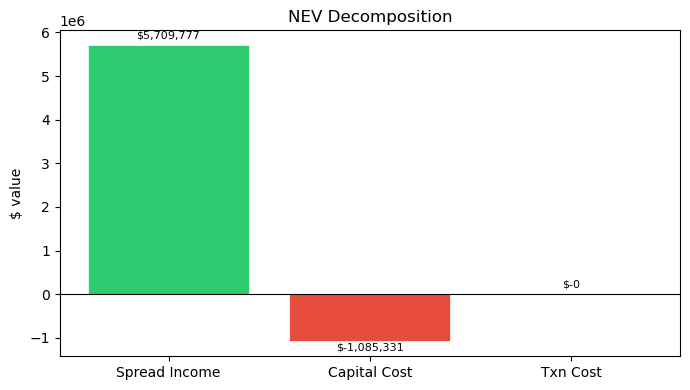

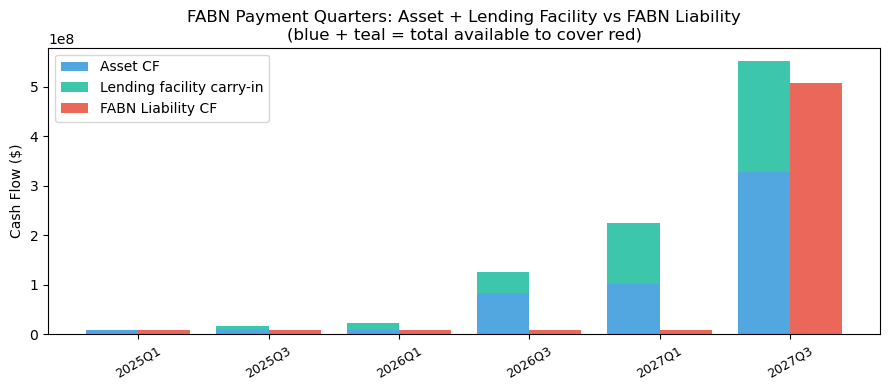

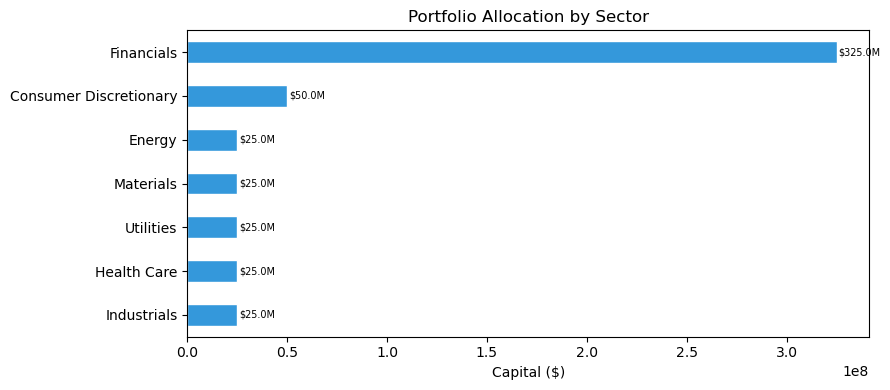

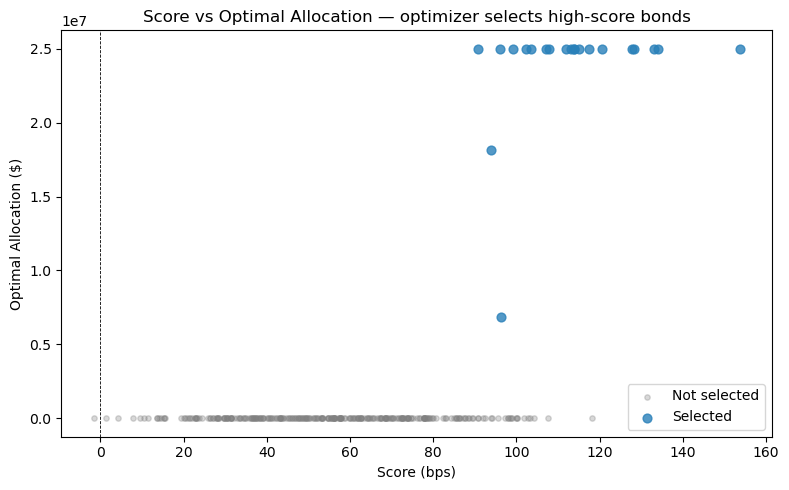

In [8]:
# =============================================================================
# 4. ANALYTICS  —  always run
# =============================================================================

# ---------------------------------------------------------------------------
# 4A. NEV SUMMARY TABLE
# ---------------------------------------------------------------------------
nev_summary = pd.DataFrame({
    "Component"  : [
        "Spread Income",
        "Capital Cost  (C1 + C3)",
        "  - C1 Credit Risk",
        "  - C3 Duration Mismatch",
        "Transaction Costs",
        "NET ECONOMIC VALUE",
    ],
    "Value ($)"  : [
        spread_income_val,
        -capital_cost_val,
        -C1_val,
        -C3_val,
        -txn_cost_val,
        nev_val,
    ],
})
display(nev_summary)

# ---------------------------------------------------------------------------
# 4B. PORTFOLIO ANALYTICS  (weighted averages over allocated bonds)
# ---------------------------------------------------------------------------
fixed_df  = pipeline["fixed"].set_index("CUSIP")
selected  = h_opt > 1.0                          # bonds with non-trivial allocation
w         = h_opt[selected] / h_opt[selected].sum()   # weights within selected bonds

analytics = pd.DataFrame({
    "Metric": [
        "Bonds selected  (h > $1)",
        "Weighted avg spread  (bps)",
        "Weighted avg duration  (yrs)",
        "Weighted avg C-1 charge  (%)",
        "Weighted avg score  (bps)",
        "Total C-1 capital charge  ($)",
        "Duration gap  (D_avg - D_FABN)  (yrs)",
        "RBC ratio  (x)",
    ],
    "Value": [
        int(selected.sum()),
        f"{(spread[selected] * w).sum() * 1e4:.2f}",
        f"{(durs[selected] * w).sum():.4f}",
        f"{(theta[selected] * w).sum() * 100:.3f}",
        f"{(score[selected] * w).sum() * 1e4:.2f}",
        f"${(theta * h_opt).sum():,.0f}",
        f"{D_avg - D_FABN:+.4f}",
        f"{RBC_val:.2f}x",
    ],
})
display(analytics)

# ---------------------------------------------------------------------------
# 4C. ALLOCATION TABLE  (non-zero bonds only, sorted by allocation descending)
# ---------------------------------------------------------------------------
alloc_df = pd.DataFrame({
    "CUSIP"        : CUSIPS,
    "Sector"       : [str(fixed_df.loc[c, "sector"]) for c in CUSIPS],
    "Rating (S&P)" : [str(fixed_df.loc[c, "rating_sp"]).strip() for c in CUSIPS],
    "h_opt ($)"    : h_opt,
    "h_curr ($)"   : h_curr,
    "Delta ($)"    : h_opt - h_curr,
    "Spread (bps)" : spread * 1e4,
    "Duration (yr)": durs,
    "Score (bps)"  : score * 1e4,
    "C1 charge ($)": theta * h_opt,
})
alloc_nonzero = (
    alloc_df[alloc_df["h_opt ($)"] > 1.0]
    .sort_values("h_opt ($)", ascending=False)
    .reset_index(drop=True)
)
print(f"Non-zero allocations: {len(alloc_nonzero)} / {N} bonds")
display(alloc_nonzero)

# ---------------------------------------------------------------------------
# 4D. CHARTS
# ---------------------------------------------------------------------------

# ── Fig 1: NEV Decomposition ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
components = [spread_income_val, -capital_cost_val, -txn_cost_val]
labels     = ["Spread Income", "Capital Cost", "Txn Cost"]
colors     = ["#2ecc71" if v >= 0 else "#e74c3c" for v in components]
bars = ax.bar(labels, components, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("NEV Decomposition")
ax.set_ylabel("$ value")
for bar, val in zip(bars, components):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (max(components) * 0.02 if val >= 0 else min(components) * 0.02),
            f"${val:,.0f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=8)
plt.tight_layout()
plt.show()

# ── Fig 2: Quarterly Cash Flow Coverage (FABN payment quarters only) ─────────
# Only shows quarters where the FABN has a non-zero payment.
# Asset bar is stacked: blue = asset CF, teal = lending facility carry-in.
# When blue + teal >= red, that payment is fully covered.
fabn_pay_idx = [q for q in range(Q) if float(qtr_fabn_cf[q]) > 0]

facility_carry = [0.0] + [B[q - 1].X * (1.0 + r_lend * dt_q) for q in range(1, Q)]

pay_labels    = [str(qtr_idx[q]) for q in fabn_pay_idx]
pay_asset     = [CF_A_vals[q]      for q in fabn_pay_idx]
pay_facility  = [facility_carry[q] for q in fabn_pay_idx]
pay_liability = [float(qtr_fabn_cf[q]) for q in fabn_pay_idx]

fig, ax = plt.subplots(figsize=(9, 4))
x     = range(len(fabn_pay_idx))
width = 0.4

ax.bar([i - width / 2 for i in x], pay_asset,     width,
       label="Asset CF",                  color="#3498db", alpha=0.85)
ax.bar([i - width / 2 for i in x], pay_facility,  width,
       bottom=pay_asset,
       label="Lending facility carry-in", color="#1abc9c", alpha=0.85)
ax.bar([i + width / 2 for i in x], pay_liability, width,
       label="FABN Liability CF",         color="#e74c3c", alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(pay_labels, rotation=30, fontsize=9)
ax.set_title("FABN Payment Quarters: Asset + Lending Facility vs FABN Liability\n"
             "(blue + teal = total available to cover red)")
ax.set_ylabel("Cash Flow ($)")
ax.legend()
plt.tight_layout()
plt.show()

# ── Fig 3: Sector Allocation ────────────────────────────────────────────────
sector_alloc = {}
for i, cusip in enumerate(CUSIPS):
    sec = str(fixed_df.loc[cusip, "sector"])
    sector_alloc[sec] = sector_alloc.get(sec, 0.0) + h_opt[i]
sector_s = pd.Series(sector_alloc).sort_values(ascending=True)
sector_s = sector_s[sector_s > 0]   # hide sectors with zero allocation

fig, ax = plt.subplots(figsize=(9, max(4, len(sector_s) * 0.4)))
sector_s.plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
ax.set_title("Portfolio Allocation by Sector")
ax.set_xlabel("Capital ($)")
for bar in ax.patches:
    ax.text(bar.get_width() + H * 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"${bar.get_width() / 1e6:.1f}M",
            va="center", fontsize=7)
plt.tight_layout()
plt.show()

# ── Fig 4: Score vs Allocation Scatter ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
not_sel = ~selected
ax.scatter(score[not_sel] * 1e4, h_opt[not_sel],
           alpha=0.3, color="grey",     s=15, label="Not selected")
ax.scatter(score[selected] * 1e4, h_opt[selected],
           alpha=0.8, color="#2980b9",  s=40, label="Selected")
ax.set_xlabel("Score (bps)")
ax.set_ylabel("Optimal Allocation ($)")
ax.set_title("Score vs Optimal Allocation — optimizer selects high-score bonds")
ax.legend()
ax.axvline(0, color="black", linewidth=0.6, linestyle="--")
plt.tight_layout()
plt.show()